In [53]:
import numpy as np
import pandas as pd
import xgboost as xgb

import seaborn as sns

model = xgb.Booster()
model.load_model("data/model_weights/xgb_decision_tree.json")

model_df = model.trees_to_dataframe()

In [54]:
model_df.head(20)

,Tree,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover,Category
0,0,0,0-0,e23,NaN,0-2,0-1,0-1,6800.428710,8537.902340,[0]
1,0,1,0-1,e27,NaN,0-4,0-3,0-3,101.343628,6875.554690,[0]
2,0,2,0-2,e21,NaN,0-6,0-5,0-5,4266.115720,1662.347170,[0]
3,0,3,0-3,e24,NaN,0-8,0-7,0-7,141.440460,2258.101560,[0]
4,0,4,0-4,e33,NaN,0-10,0-9,0-9,5.450317,4617.453120,[0]
5,0,5,0-5,e10,NaN,0-12,0-11,0-11,1142.761720,1008.227290,[0]
6,0,6,0-6,e58,NaN,0-14,0-13,0-13,118.770187,654.119934,[0]
7,0,7,0-7,Leaf,NaN,NaN,NaN,NaN,-0.355048,1482.090580,NaN
8,0,8,0-8,Leaf,NaN,NaN,NaN,NaN,0.066405,776.011169,NaN
9,0,9,0-9,Leaf,NaN,NaN,NaN,NaN,-0.376682,1507.180540,NaN


In [55]:
# Boundaries are calculated below
quant_boundaries = np.array([-0.78268069, -0.27526352, -0.08869842,  0.11034979,  3.03155756])

# quantizer: used to quantize the leaf
def quantize_leaf(leaf_value):
  quantized_leaf_value = np.digitize(leaf_value, quant_boundaries[1:-1]).item()
  return quantized_leaf_value

In [56]:
node_index = model_df.set_index("ID")

# Pre-extract columns as plain dicts for fastest access
feature_map = node_index["Feature"].to_dict()
gain_map    = node_index["Gain"].to_dict()
yes_map     = node_index["Yes"].to_dict()
no_map      = node_index["No"].to_dict()

# ── 2. Iterative (not recursive) tree traversal ─────────────────────────────
def calculate_tree(root_id: str, embedding: np.ndarray) -> float:
    node = root_id
    while True:
      feature = feature_map[node]
      if feature == "Leaf":
        return quantize_leaf(gain_map[node])
      ex  = int(feature[1:])          # strip leading 'e'
      node = yes_map[node] if embedding[ex] == -1 else no_map[node]


num_classes = 10
num_rounds  = model.num_boosted_rounds()

# Pre-build root IDs once
root_ids = [
  [f"{r * num_classes + cl}-0" for r in range(num_rounds)]
  for cl in range(num_classes)
]

def make_decision(embedding: np.ndarray) -> np.ndarray:
  return np.array([
    sum(calculate_tree(root, embedding) for root in roots)
    for roots in root_ids
  ])


In [57]:
# Example embedding for label 0
embedding = np.array([ 1, -1,  1, -1, -1, -1, -1, -1,  1, -1,  1, -1,  1, -1,  1,  1,  1,
       -1, -1,  1,  1,  1,  1, -1,  1,  1, -1,  1, -1, -1, -1, -1, -1,  1,
       -1,  1,  1, -1,  1,  1,  1, -1, -1,  1,  1, -1,  1,  1,  1,  1,  1,
       -1, -1,  1, -1,  1,  1,  1, -1, -1,  1, -1,  1, -1], dtype=np.int8)

activation = make_decision(embedding)
np.argmax(activation)

np.int64(2)

In [58]:
validation_dataset = pd.read_parquet("data/embedding_table/val_embeddings.parquet")

feature_cols = [f"e{i}" for i in range(64)]
embeddings   = validation_dataset[feature_cols].to_numpy(dtype=np.int8)
labels       = validation_dataset["label"].to_numpy()
dataset_size = len(labels)

corrects = 0
for idx in range(dataset_size):
  activation = make_decision(embeddings[idx])
  corrects  += np.argmax(activation) == labels[idx]

  if idx % 2000 == 0:
    print(f"Progress: {idx / dataset_size * 100:.1f}%")

print(f"Accuracy: {corrects / dataset_size:.4f}")

Progress: 0.0%
Progress: 20.0%
Progress: 40.0%
Progress: 60.0%
Progress: 80.0%
Accuracy: 0.7073


<Axes: ylabel='Count'>

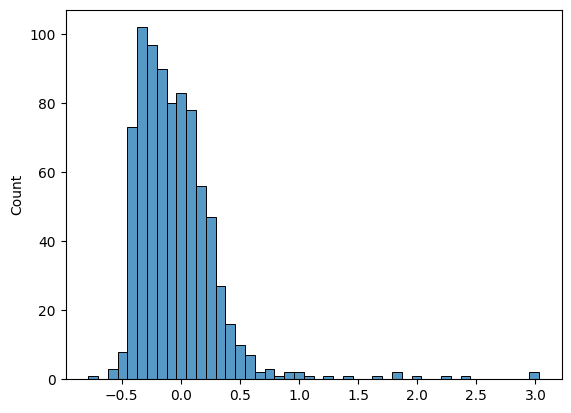

In [59]:
leafs_df = model_df[model_df["Feature"] == "Leaf"]
leaf_values = leafs_df["Gain"].values
sns.histplot(leaf_values)

array([-0.78268069, -0.36558776, -0.29033118, -0.21646205, -0.13786605,
       -0.04714617,  0.04427217,  0.13771298,  0.27884599,  3.03155756])

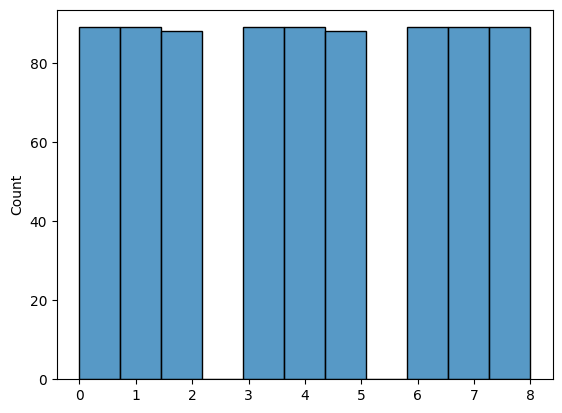

In [60]:
num_quantized_bits = 3
percentiles = np.linspace(0, 100, num_quantized_bits**2+1)
boundaries = np.percentile(leaf_values, percentiles)

sns.histplot(np.digitize(leaf_values, boundaries[1:-1]))
boundaries